# Clasificación - NO2

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline

In [4]:
archivo = "/content/NO2_daily_aqs_data_downloaded_2026-09-17 19_56_09.csv"
df = pd.read_csv(archivo)
df.head()

,Date,Site ID,POC,Daily Max NO2 Concentration,Units,Daily AQI Value,Local Site Name,Daily Obs Count,Percent Complete,AQS Parameter Code,...,Elevation (m),Measurement Scale,Measurement Scale Definition,Monitor Type,Monitoring Agency,Monitoring Objective,NAAQS Primary Monitor?,Networks,Probe Height (m),QA Primary Monitor?
0,2022-01-01,410510080,1,22.4,Parts per billion,21,Portland - SE Lafayette St (SEL),24,100,42602,...,69,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Oregon Department Of Environmental Quality,GENERAL/BACKGROUND,Y,PROPOSED NCORE,6,NaN
1,2022-01-02,410510080,1,11.8,Parts per billion,10,Portland - SE Lafayette St (SEL),24,100,42602,...,69,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Oregon Department Of Environmental Quality,GENERAL/BACKGROUND,Y,PROPOSED NCORE,6,NaN
2,2022-01-03,410510080,1,9.1,Parts per billion,8,Portland - SE Lafayette St (SEL),23,96,42602,...,69,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Oregon Department Of Environmental Quality,GENERAL/BACKGROUND,Y,PROPOSED NCORE,6,NaN
3,2022-01-04,410510080,1,21.5,Parts per billion,20,Portland - SE Lafayette St (SEL),24,100,42602,...,69,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Oregon Department Of Environmental Quality,GENERAL/BACKGROUND,Y,PROPOSED NCORE,6,NaN
4,2022-01-05,410510080,1,23.9,Parts per billion,22,Portland - SE Lafayette St (SEL),24,100,42602,...,69,NEIGHBORHOOD,500 M TO 4KM,SLAMS,Oregon Department Of Environmental Quality,GENERAL/BACKGROUND,Y,PROPOSED NCORE,6,NaN


### info()


In [5]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 661 entries, 0 to 660
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Date                          661 non-null    object 
 1   Site ID                       661 non-null    int64  
 2   POC                           661 non-null    int64  
 3   Daily Max NO2 Concentration   661 non-null    float64
 4   Units                         661 non-null    object 
 5   Daily AQI Value               661 non-null    int64  
 6   Local Site Name               661 non-null    object 
 7   Daily Obs Count               661 non-null    int64  
 8   Percent Complete              661 non-null    int64  
 9   AQS Parameter Code            661 non-null    int64  
 10  AQS Parameter Description     661 non-null    object 
 11  Method Code                   661 non-null    int64  
 12  Method Description            661 non-null    object 
 13  CBSA 

## describe()
*>> resumen de estadísticas*

In [6]:
df.describe()

,Site ID,POC,Daily Max NO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,AQS Parameter Code,Method Code,CBSA Code,Site Latitude,Site Longitude,Elevation (m),Probe Height (m),QA Primary Monitor?
count,661.0,661.0,661.000000,661.000000,661.000000,661.000000,661.0,661.0,661.0,6.610000e+02,6.610000e+02,661.0,661.0,0.0
mean,410510080.0,1.0,13.415431,12.260212,23.242057,96.877458,42602.0,200.0,38900.0,4.549664e+01,-1.226029e+02,69.0,6.0,NaN
std,0.0,0.0,7.899070,7.459511,2.506135,10.409864,0.0,0.0,0.0,6.115295e-13,1.279945e-12,0.0,0.0,NaN
min,410510080.0,1.0,2.100000,2.000000,3.000000,13.000000,42602.0,200.0,38900.0,4.549664e+01,-1.226029e+02,69.0,6.0,NaN
25%,410510080.0,1.0,7.500000,7.000000,24.000000,100.000000,42602.0,200.0,38900.0,4.549664e+01,-1.226029e+02,69.0,6.0,NaN
50%,410510080.0,1.0,12.000000,11.000000,24.000000,100.000000,42602.0,200.0,38900.0,4.549664e+01,-1.226029e+02,69.0,6.0,NaN
75%,410510080.0,1.0,18.200000,17.000000,24.000000,100.000000,42602.0,200.0,38900.0,4.549664e+01,-1.226029e+02,69.0,6.0,NaN
max,410510080.0,1.0,70.600000,68.000000,24.000000,100.000000,42602.0,200.0,38900.0,4.549664e+01,-1.226029e+02,69.0,6.0,NaN


## Datos que usaremos

In [7]:
df_modelo = df[['Daily Max NO2 Concentration',
                 'Daily AQI Value',
                 'Daily Obs Count',
                 'Percent Complete']].copy()

df_modelo.head()

,Daily Max NO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete
0,22.4,21,24,100
1,11.8,10,24,100
2,9.1,8,23,96
3,21.5,20,24,100
4,23.9,22,24,100


### Creamos TARGET CLASS
Usamos la mediana de `Daily AQI Value` para separar los datos en dos clases.

In [8]:
mediana_aqi = df_modelo['Daily AQI Value'].median()
mediana_aqi

11.0

In [9]:
df_modelo['TARGET CLASS'] = np.where(
    df_modelo['Daily AQI Value'] > mediana_aqi, 1, 0
)

df_modelo.head()

,Daily Max NO2 Concentration,Daily AQI Value,Daily Obs Count,Percent Complete,TARGET CLASS
0,22.4,21,24,100,1
1,11.8,10,24,100,0
2,9.1,8,23,96,0
3,21.5,20,24,100,1
4,23.9,22,24,100,1


In [10]:
df_modelo['TARGET CLASS'].value_counts()

,count
TARGET CLASS,
0,363
1,298


In [11]:
l = list(df_modelo.columns)
print(l)

['Daily Max NO2 Concentration', 'Daily AQI Value', 'Daily Obs Count', 'Percent Complete', 'TARGET CLASS']


### Boxplots

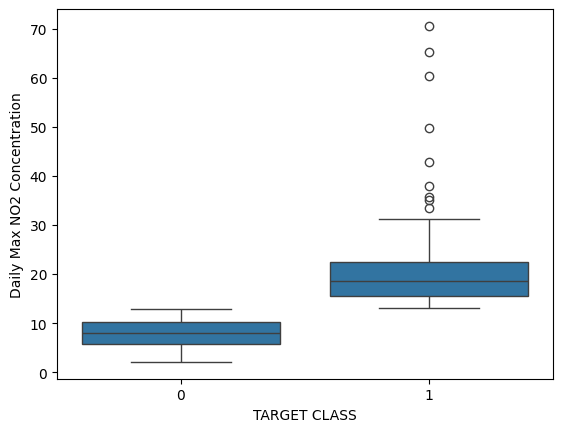

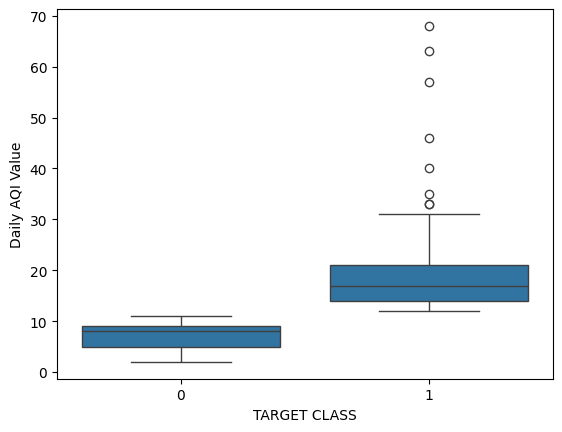

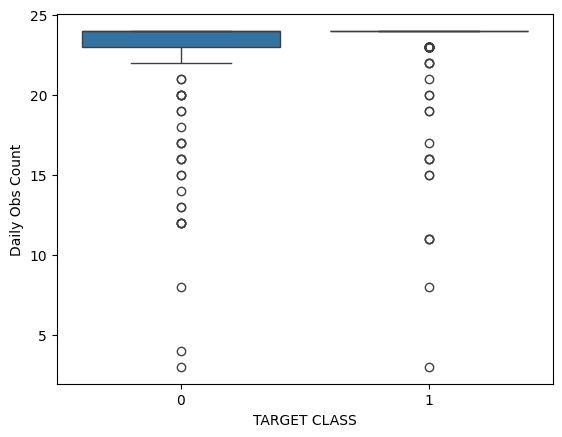

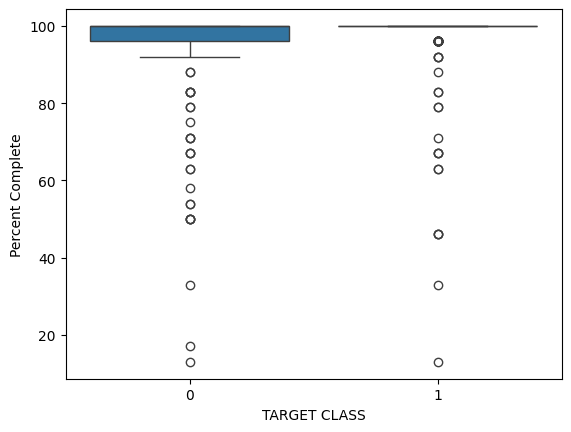

In [12]:
for i in range(len(l)-1):
    plt.figure()
    sns.boxplot(x='TARGET CLASS', y=l[i], data=df_modelo)
    plt.show()

# Escalamos características

### Preprocesamiento

In [13]:
from sklearn.preprocessing import StandardScaler

### Meta: predecir TARGET CLASS

# División entrenamiento-prueba
### Ajuste del modelo y predicción

In [14]:
from sklearn.model_selection import train_test_split

In [15]:
X = df_modelo[['Daily Max NO2 Concentration',
               'Daily Obs Count',
               'Percent Complete']]
y = df_modelo['TARGET CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=101
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

#KNN
### (K-Nearest Neighbors)
* Decide a qué clase pertenece un nuevo dato observando qué clase tienen sus vecinos más cercanos.

In [19]:
from sklearn.neighbors import KNeighborsClassifier

In [20]:
k = 11
knn = KNeighborsClassifier(n_neighbors=k)
knn.fit(X_train, y_train)

KNeighborsClassifier(n_neighbors=11)

In [21]:
pred = knn.predict(X_test)

### Evaluación de la calidad de clasificación

In [22]:
from sklearn.metrics import classification_report, confusion_matrix

In [23]:
conf_mat = confusion_matrix(y_test, pred)
print(conf_mat)

[[104   0]
 [  8  87]]


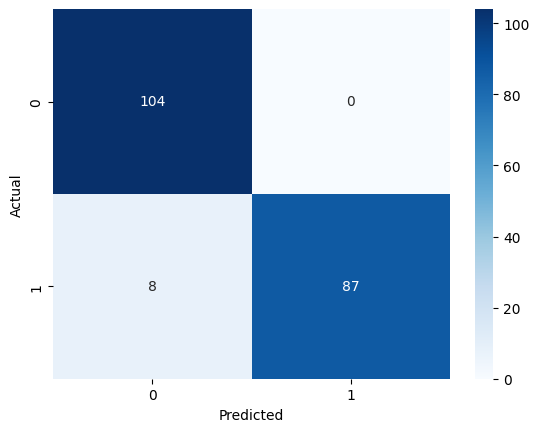

In [24]:
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [25]:
print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.93      1.00      0.96       104
           1       1.00      0.92      0.96        95

    accuracy                           0.96       199
   macro avg       0.96      0.96      0.96       199
weighted avg       0.96      0.96      0.96       199



In [26]:
print("Tasa de error de clasificación errónea:",
      round(np.mean(pred != y_test), 3))

Tasa de error de clasificación errónea: 0.04


# Elegimos 'k' por el método del *elbow*

In [27]:
error_rate = []

for i in range(1, 60):
    knn = KNeighborsClassifier(n_neighbors=i)
    knn.fit(X_train, y_train)
    pred_i = knn.predict(X_test)
    error_rate.append(np.mean(pred_i != y_test))

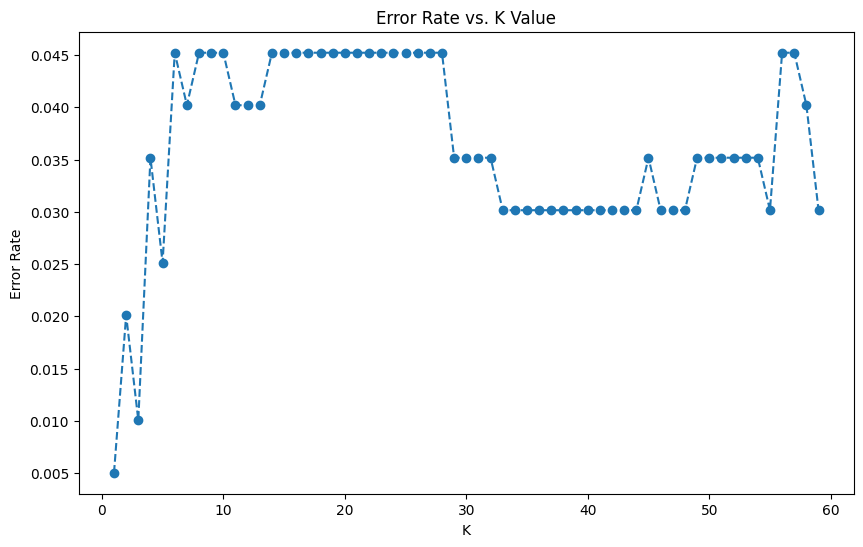

In [28]:
plt.figure(figsize=(10,6))
plt.plot(range(1,60), error_rate,
         linestyle='dashed',
         marker='o',
         markersize=6)
plt.title('Error Rate vs. K Value')
plt.xlabel('K')
plt.ylabel('Error Rate')
plt.show()

* Se observa cómo cambia el error según el valor de K.

#
Naive Bayes

### Estadística básica

In [29]:
df_modelo.iloc[:,:-1].describe().T

,count,mean,std,min,25%,50%,75%,max
Daily Max NO2 Concentration,661.0,13.415431,7.899070,2.1,7.5,12.0,18.2,70.6
Daily AQI Value,661.0,12.260212,7.459511,2.0,7.0,11.0,17.0,68.0
Daily Obs Count,661.0,23.242057,2.506135,3.0,24.0,24.0,24.0,24.0
Percent Complete,661.0,96.877458,10.409864,13.0,100.0,100.0,100.0,100.0


### Boxplots

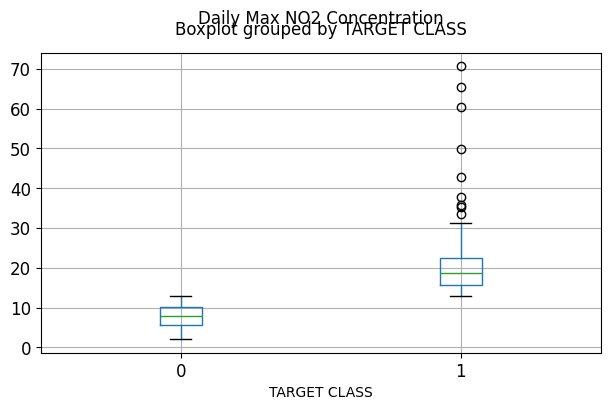

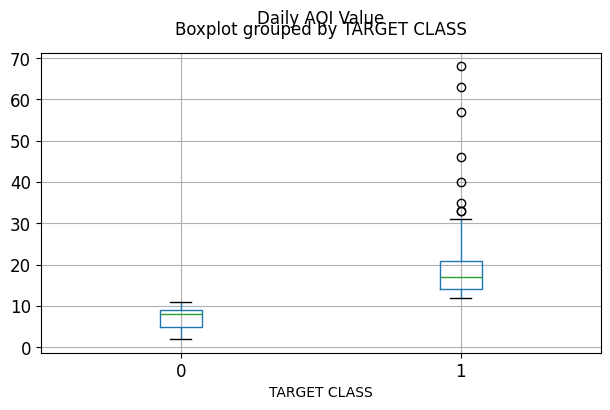

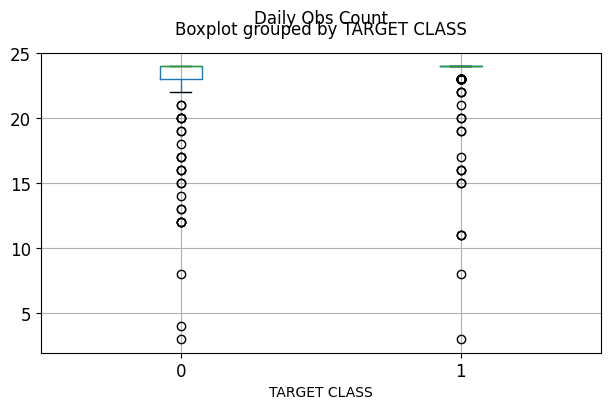

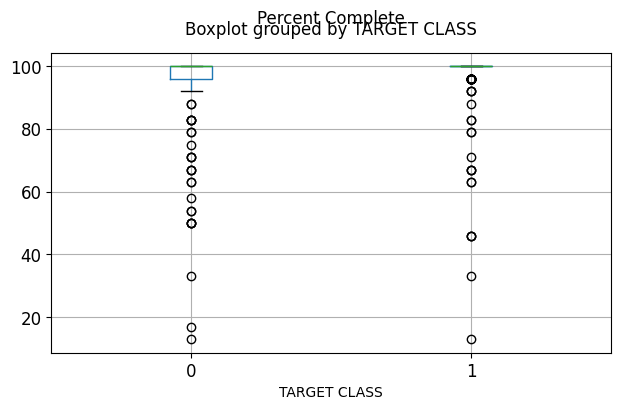

In [30]:
for c in df_modelo.columns[:-1]:
    df_modelo.boxplot(c, by='TARGET CLASS', figsize=(7,4), fontsize=12)
    plt.title("{}\n".format(c))
    plt.xlabel("TARGET CLASS")
    plt.show()

### Gráfico de dispersión

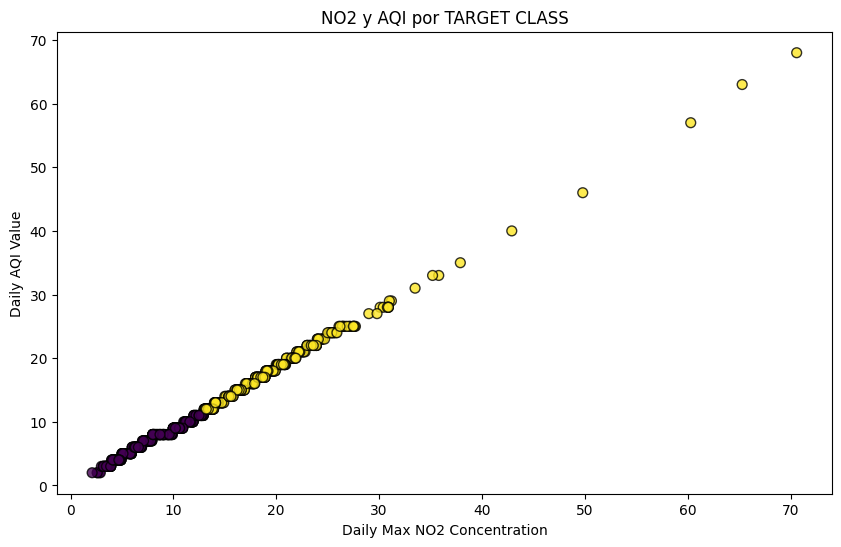

In [31]:
plt.figure(figsize=(10,6))
plt.scatter(
    df_modelo['Daily Max NO2 Concentration'],
    df_modelo['Daily AQI Value'],
    c=df_modelo['TARGET CLASS'],
    edgecolors='k',
    alpha=0.8,
    s=50
)
plt.xlabel('Daily Max NO2 Concentration')
plt.ylabel('Daily AQI Value')
plt.title('NO2 y AQI por TARGET CLASS')
plt.show()

### ¿Son las funciones independientes? 🤔

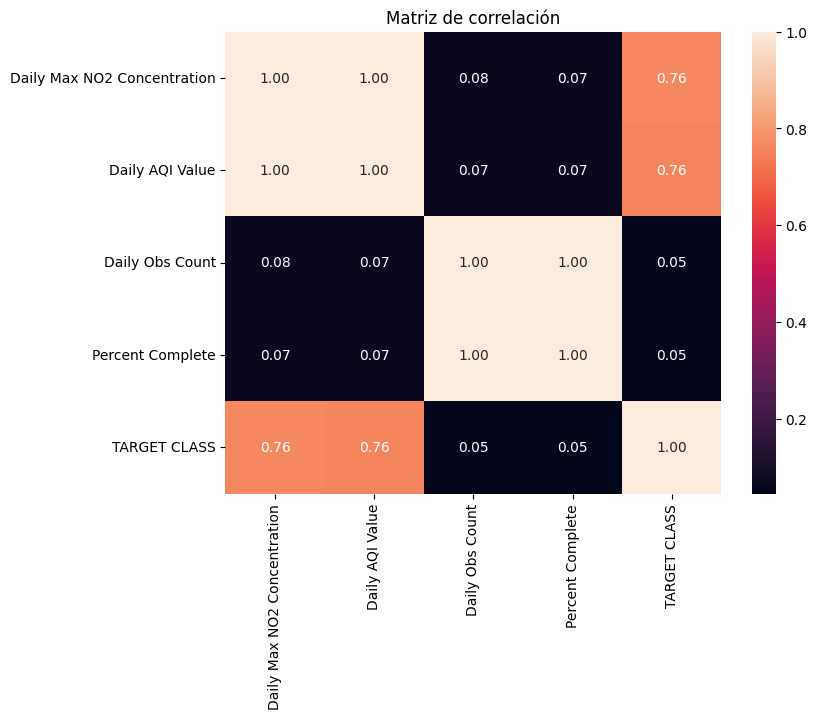

In [32]:
corr = df_modelo.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

### Clasificación Naive Bayes

In [33]:
X1 = df_modelo[['Daily Max NO2 Concentration',
                'Daily Obs Count',
                'Percent Complete']]
y1 = df_modelo['TARGET CLASS']

X1_train, X1_test, y1_train, y1_test = train_test_split(
    X1, y1, test_size=0.30, random_state=101
)

In [34]:
X1.head() # muestra las 5 primeras filas de X1

,Daily Max NO2 Concentration,Daily Obs Count,Percent Complete
0,22.4,24,100
1,11.8,24,100
2,9.1,23,96
3,21.5,24,100
4,23.9,24,100


* Clasificación GaussianNB: aprende las características de cada clase y calcula a qué clase es más probable que pertenezca un nuevo dato.

In [35]:
from sklearn.naive_bayes import GaussianNB

In [36]:
nbc = GaussianNB()

In [37]:
nbc.fit(X1_train, y1_train) # entrenamos X1 y Y1

GaussianNB()

In [38]:
y1_pred = nbc.predict(X1_test)
mislabel = np.sum(y1_test != y1_pred)

print("La cantidad total de puntos de datos mal etiquetados de {} muestras de prueba es {}".format(
    len(y1_test), mislabel
))

La cantidad total de puntos de datos mal etiquetados de 199 muestras de prueba es 10


In [39]:
print("El informe de clasificación es el siguiente...\n")
print(classification_report(y1_test, y1_pred))

El informe de clasificación es el siguiente...

              precision    recall  f1-score   support

           0       0.98      0.92      0.95       104
           1       0.92      0.98      0.95        95

    accuracy                           0.95       199
   macro avg       0.95      0.95      0.95       199
weighted avg       0.95      0.95      0.95       199



In [40]:
cm = confusion_matrix(y1_test, y1_pred)

cmdf = pd.DataFrame(
    cm,
    index=['Class 0', 'Class 1'],
    columns=['Class 0', 'Class 1']
)

cmdf

,Class 0,Class 1
Class 0,96,8
Class 1,2,93


#Kappa (Cohen) y Validación Cruzada en Clasificación

In [41]:
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, cohen_kappa_score, make_scorer, ConfusionMatrixDisplay

In [42]:
X2 = df_modelo[['Daily Max NO2 Concentration',
                'Daily Obs Count',
                'Percent Complete']]

y2 = df_modelo['TARGET CLASS']

print(X2.shape)
print(y2.value_counts())

(661, 3)
TARGET CLASS
0    363
1    298
Name: count, dtype: int64


## Cohen's kappa (k)

Es una medida del grado de acuerdo entre dos evaluadores:

* El modelo
* La etiqueta real

Interpretación:

* **k = 1**: acuerdo perfecto
* **k = 0**: acuerdo esperado por azar
* **k < 0**: acuerdo peor que el azar

In [43]:
X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2,
    test_size=0.25,
    random_state=42,
    stratify=y2
)

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, random_state=42))
])

pipe.fit(X2_train, y2_train)

pred2 = pipe.predict(X2_test)

accuracy = accuracy_score(y2_test, pred2)
kappa = cohen_kappa_score(y2_test, pred2)

print("Accuracy:", accuracy)
print("Kappa:", kappa)
print()
print(classification_report(y2_test, pred2))

Accuracy: 0.9879518072289156
Kappa: 0.9756205022763988

              precision    recall  f1-score   support

           0       0.98      1.00      0.99        91
           1       1.00      0.97      0.99        75

    accuracy                           0.99       166
   macro avg       0.99      0.99      0.99       166
weighted avg       0.99      0.99      0.99       166



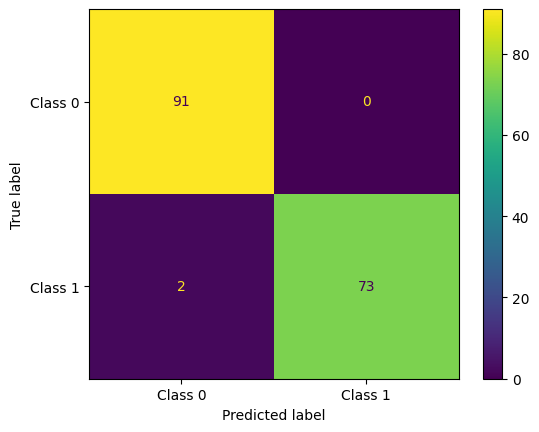

In [44]:
cm2 = confusion_matrix(y2_test, pred2)

disp2 = ConfusionMatrixDisplay(
    confusion_matrix=cm2,
    display_labels=['Class 0', 'Class 1']
)

disp2.plot()
plt.show()

### Cross-Validation
Validación cruzada

> Estima el rendimiento del modelo de forma más robusta que un solo split train/test.

K-fold CV:

* Se divide el conjunto de datos en varias partes.
* Una parte se usa para evaluación y las demás para entrenamiento.
* El proceso se repite varias veces.

In [45]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "accuracy": "accuracy",
    "kappa": make_scorer(cohen_kappa_score)
}

results = cross_validate(
    pipe,
    X2,
    y2,
    cv=cv,
    scoring=scoring,
    return_train_score=False
)

print("Accuracy por fold:", results["test_accuracy"])
print("Kappa por fold:", results["test_kappa"])

print()
print("Accuracy promedio:",
      results["test_accuracy"].mean(),
      "+/-",
      results["test_accuracy"].std())

print("Kappa promedio:",
      results["test_kappa"].mean(),
      "+/-",
      results["test_kappa"].std())

Accuracy por fold: [0.9924812  0.98484848 0.98484848 0.98484848 0.99242424]
Kappa por fold: [0.98483985 0.96935933 0.96935933 0.96925227 0.98465116]

Accuracy promedio: 0.9878901799954433 +/- 0.00372534407824957
Kappa promedio: 0.9754923892841527 +/- 0.007555475047422689


* `fit_time`: tiempo que tarda el computador en entrenar el modelo en cada fold.
* `score_time`: tiempo que tarda en evaluar o puntuar el modelo.

### Distribución de métricas por fold

In [46]:
df3 = pd.DataFrame({
    "accuracy": results["test_accuracy"],
    "kappa": results["test_kappa"],
})

df3

,accuracy,kappa
0,0.992481,0.984840
1,0.984848,0.969359
2,0.984848,0.969359
3,0.984848,0.969252
4,0.992424,0.984651


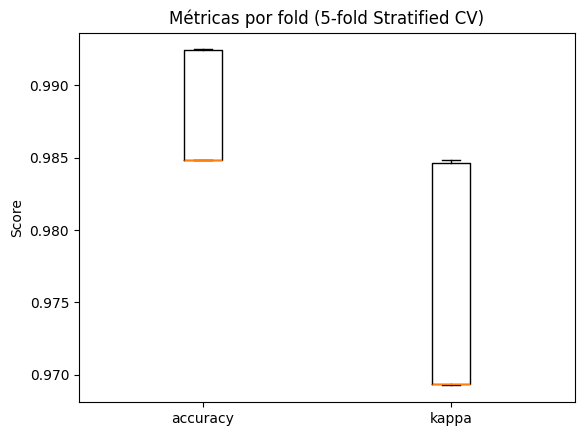

In [47]:
plt.figure()
plt.boxplot(
    [df3["accuracy"], df3["kappa"]],
    tick_labels=["accuracy", "kappa"]
)
plt.title("Métricas por fold (5-fold Stratified CV)")
plt.ylabel("Score")
plt.show()